# protein-wise-simulation
6.24.25

An (hopefully) improved implementation of the quants matrix simulation. Quick pseudocode: 

1. For each row (protein) in the matrix, pull from a Gaussian distribution to get the mean and a different Gaussian to get the standard deviation.
    - Matrix A and B will have the same mean and std, for each row
2. For 15% of rows, perturb the mean in matrix B
    - The nature of this perturbation will vary…the more you perturb, the harder the task becomes
4. For each row, simulate protein quants by drawing from a Gaussian with the pre-set mean and standard deviation.

In [654]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plotting templates
sns.set(context="talk", style="ticks") 
pal = sns.color_palette()

#### Configs

In [668]:
rand_seed=34758098
rng=np.random.default_rng(rand_seed)

# For generating the initial data distributions
quants_mean=12
quants_std=1.0
nrows=10000
ncols=128

# For simulating differential abundance
upreg_frac=0.1
downreg_frac=0.1

# Smaller values of this make the DA identification task harder 
upreg_p=0.6
downreg_p=0.6

# For simulating missingness
q_anchor=0.2
t_std=1.0
brnl_prob=0.7
mcar_frac=0.0

#### Functions

In [669]:
def simulate_mnar(
	mat, 
	q_anchor=0.2, 
	t_std=0.1, 
	brnl_prob=0.5, 
):
	"""
    Simulates some fixed (?) percentage of MNAR missingness. 
    
	Parameters
	----------
	mat : np.ndarray, 
		The unpartitioned peptide/protein quants matrix
	q_anchor : float, 
		The percentile of the abundance values on which to 
		anchor the thresholds matrix
	t_std : float, 
		How many standard deviations of the quants matrix to use 
		when constructing the thresholds matrix? 
	brnl_prob : float, 
		The probability of success for the Bernoulli draw
	rand_state : int, 
		The integer for seeding numpy's random number generator.
		The default kis None, which will just choose a random seed,
		I think

	Returns
	-------
    mat_mv : np.ndarray, 
        The matrix, with the missing values withheld. 
	"""
	# get the specified quantile from the original matrix
	q_thresh = np.nanquantile(mat, q_anchor)
	# get the standard deviation from the original matrix
	quants_std = np.nanstd(mat)

	thresh_mat = rng.normal(
					loc=q_thresh, 
					scale=(quants_std * t_std), 
					size=mat.shape,
	)
	# no longer strictly Gaussian
	thresh_mat = np.abs(thresh_mat)

	# define the training mask
	zeros = np.zeros(shape=mat.shape)
	mask = zeros > 1

	# loop through every entry in the matrix
	for i in range(0, mat.shape[0]):
		for j in range(0, mat.shape[1]):
			quants_mat_curr = mat[i,j]
			thresh_mat_curr = thresh_mat[i,j]

			if thresh_mat_curr > quants_mat_curr: 
				# for n=1 trials, binomial == bernoulli
				success = rng.binomial(1, brnl_prob)
			else: 
				success = 0

			mask[i,j] = success

	# define the training and validation sets
	mat_mv = mat.copy()
	mat_mv[mask] = np.nan

	return mat_mv

def simulate_mcar(matrix, frac, random_state):
    """
    Introduce MCAR missing values into the simulation. 
    
    Parameters
    ----------
    matrix : array-like,
        The data matrix to split.
    frac : float, 
        The fraction of data to withhold. 
    random_state : int or numpy.random.Generator
        The random state for reproducibility.
    
    Returns
    -------
    keep_set : np.ndarray,
        The array, with the specified proportion of values masked. 
    """
    rng = np.random.default_rng(random_state)
    
    # Assign splits:
    indices = np.vstack(np.nonzero(~np.isnan(matrix)))
    rng.shuffle(indices, axis=1)

    n_withhold = int(indices.shape[1] * frac)
    n_keep = indices.shape[1] - n_withhold

    keep_idx = tuple(indices[:, :n_keep])

    keep_set = np.full(matrix.shape, np.nan)
    keep_set[keep_idx] = matrix[keep_idx]

    return keep_set

def plot_partition_distributions(orig_mat, obs_mat):
    """
    Plots histograms of the original and observed (i.e., the matrix after
    holding out a certain fraction of present values). Sanity checking, to
    make sure our MNAR partitioning scheme is working correctely. 

    Parameters
    ----------
    orig_mat : np.ndarray, 
        The original (intact) matrix, without any held out values
    obs_mat : np.ndarray, 
        The matrix after witholding a fraction of values

    Returns
    ----------
    none
	"""
    # Flatten
    orig_rav = orig_mat.ravel()
    obs_rav = obs_mat.ravel()

    # Get present values
    orig_nans = np.isnan(orig_rav)
    orig_pres = orig_rav[~orig_nans]

    obs_nans = np.isnan(obs_rav)
    obs_pres = obs_rav[~obs_nans]

    # Get the means
    orig_mean = np.around(np.mean(orig_pres), 2)
    obs_mean = np.around(np.mean(obs_pres), 2)

    # Get the medians
    orig_med = np.around(np.median(orig_pres), 2)
    obs_med = np.around(np.median(obs_pres), 2)
    
    # Plot
    plt.figure()
    plt.hist(
        orig_pres, 
        density=False, 
        bins=60, 
        linewidth=0.01, 
        color='firebrick', 
        edgecolor='firebrick', 
        alpha=1.0, 
        label="Original (med: " + str(orig_med) + ")",
    )
    plt.hist(
        obs_pres, 
        density=False, 
        bins=60, 
        linewidth=0.01, 
        color='gold', 
        edgecolor='gold', 
        alpha=0.7, 
        label="Observed (med: " + str(obs_med) + ")",
    )
    plt.minorticks_off()

    plt.xlabel("Intensity", labelpad=12)
    plt.ylabel("Counts", labelpad=12)

    leg = plt.legend(bbox_to_anchor=(1.9, 1.05))
    for lh in leg.legendHandles: 
        lh.set_alpha(1)

    #plt.ticklabel_format(style="sci", axis="x", scilimits=(0,0))
    plt.show()
    return

#### Read in some real protein quants matrices 

In [670]:
cptac_df = pd.read_csv("/net/noble/vol2/home/lincolnh/data/quant-data/UMich-quants-matrices/joint-quants-matrix-umich.csv", index_col=0)
cptac_means = np.nanmean(cptac_df, axis=1)
cptac_stds = np.nanstd(cptac_df, axis=1)

cptac_mean = np.mean(cptac_means)
cptac_std = np.mean(cptac_stds)

print(f"CPTAC mean: {np.around(cptac_mean, 2)}")
print(f"CPTAC std: {np.around(cptac_std, 2)}")
print(f"CPTAC shape: {cptac_df.shape}")

CPTAC mean: 21.55
CPTAC std: 1.38
CPTAC shape: (18988, 1905)


#### Initialize the empty matrices 

In [671]:
condA = np.ones((nrows,ncols))
condA[:] = np.nan

condB = np.ones((nrows,ncols))
condB[:] = np.nan

#### Get the means and standard deviations for each protein 

In [672]:
prot_means_a = rng.normal(loc=quants_mean, scale=quants_std*2, size=nrows)
prot_stds = np.abs(rng.normal(loc=quants_std, scale=quants_std, size=nrows))

#### Simulate differential expression 
By varying the means for one of the condition matrices. 

In [673]:
prot_means_b = prot_means_a.copy()

# Simulate up-regulated proteins
n_upreg = int(np.ceil(nrows*upreg_frac))
upreg_idx = rng.choice(range(0,nrows), n_upreg, replace=False)

perturb_vals_up = prot_means_b[upreg_idx] * upreg_p
prot_means_b[upreg_idx] += perturb_vals_up

# Simulate down-regulated proteins
n_downreg = int(np.ceil(nrows*downreg_frac))
downreg_idx = rng.choice(range(0,nrows), n_downreg, replace=False)

perturb_vals_down = prot_means_b[downreg_idx] * downreg_p
prot_means_b[downreg_idx] -= perturb_vals_down

#### Fill in the quants for each protein
For both condition matrices. 

In [674]:
prot_attributes_a = zip(prot_means_a, prot_stds, list(range(0,nrows)))
prot_attributes_b = zip(prot_means_b, prot_stds, list(range(0,nrows)))

for mean, std, i in prot_attributes_a:
    condA_quants = rng.normal(loc=mean, scale=std, size=ncols)
    condA[i] = np.abs(condA_quants)

for mean, std, i in prot_attributes_b:
    condB_quants = rng.normal(loc=mean, scale=std, size=ncols)
    condB[i] = np.abs(condB_quants)

#### Simulate MNAR into both matrices

In [675]:
condA_mv = simulate_mnar(condA, q_anchor, t_std, brnl_prob)
condB_mv = simulate_mnar(condB, q_anchor, t_std, brnl_prob)

mv_countA = np.count_nonzero(np.isnan(condA_mv))
mv_fracA = mv_countA / condA_mv.size

mv_countB = np.count_nonzero(np.isnan(condB_mv))
mv_fracB = mv_countB / condB_mv.size

print(f"missingness fraction, condA: {np.around(mv_fracA, 2)}")
print(f"missingness fraction, condB: {np.around(mv_fracB, 2)}")

missingness fraction, condA: 0.2
missingness fraction, condB: 0.22


#### Simulate MCAR as well
Ideally there would be far more MNAR than MCAR. But MCAR helps us get really high
overall missingess fractions. 

In [676]:
condA_mv = simulate_mcar(condA_mv, mcar_frac, 233994859)
condB_mv = simulate_mcar(condB_mv, mcar_frac, 109359480)

mv_countA = np.count_nonzero(np.isnan(condA_mv))
mv_fracA = mv_countA / condA_mv.size

mv_countB = np.count_nonzero(np.isnan(condB_mv))
mv_fracB = mv_countB / condB_mv.size

print(f"missingness fraction, condA: {np.around(mv_fracA, 2)}")
print(f"missingness fraction, condB: {np.around(mv_fracB, 2)}")

missingness fraction, condA: 0.2
missingness fraction, condB: 0.22


#### Sanity check 

/tmp/ipykernel_4164695/4272682453.py:167: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


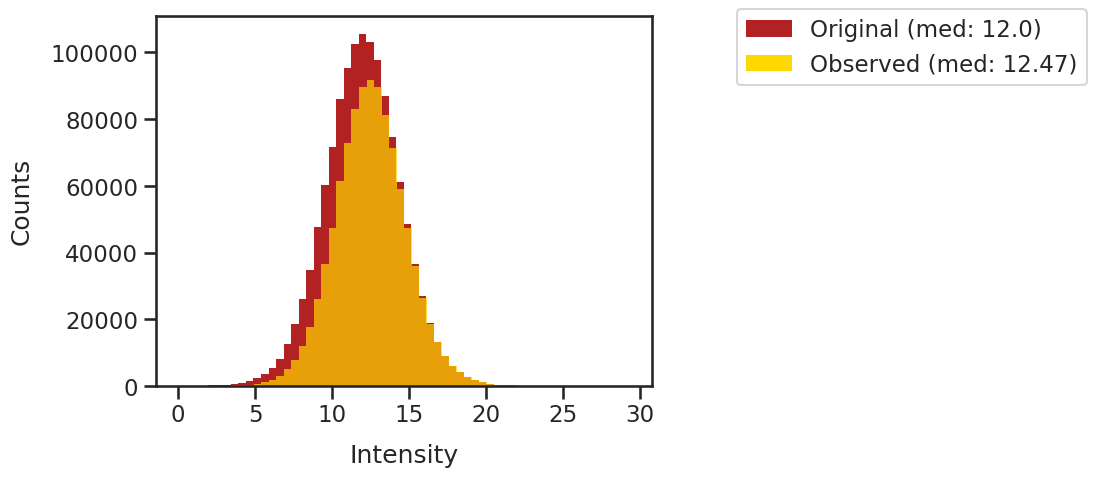

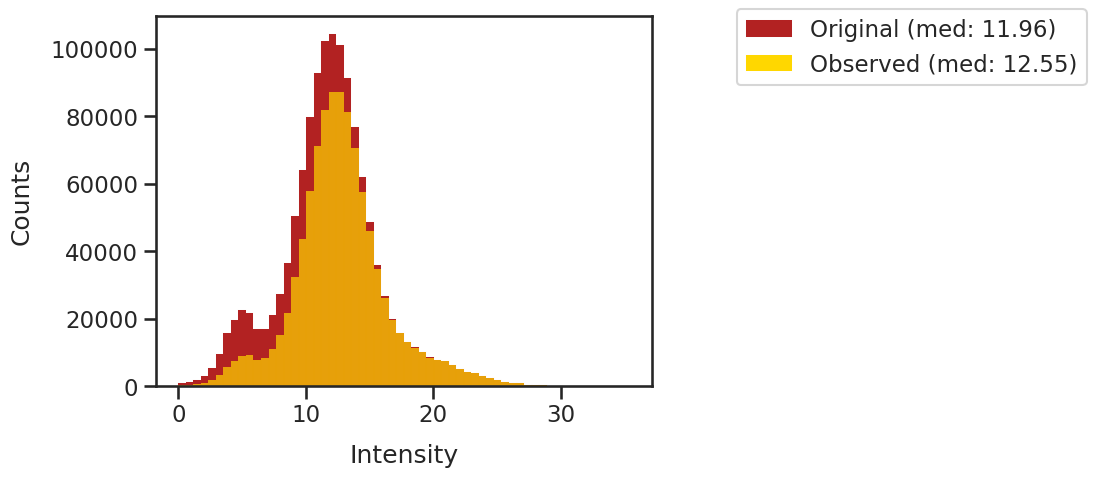

In [677]:
plot_partition_distributions(condA, condA_mv)
plot_partition_distributions(condB, condB_mv)

#### Assign runs and protein IDs
So that we can keep track of which runs come from which condition and which proteins are differentially abundant.
Lets pull protein IDs directly from CPTAC ENSPs....because why not?

In [678]:
condA_df = pd.DataFrame(condA_mv)
condA_colnames = ["condA-run"+str(x) for x in condA_df.columns]
condA_df.columns = condA_colnames
#mat0_df

condB_df = pd.DataFrame(condB_mv)
condB_colnames = ["condB-run"+str(x) for x in condB_df.columns]
condB_df.columns = condB_colnames
#mat1_df

condA_df.index = cptac_df.index[:nrows]
condB_df.index = cptac_df.index[:nrows]

#### Combine into a single dataframe and write 

/tmp/ipykernel_4164695/4272682453.py:167: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


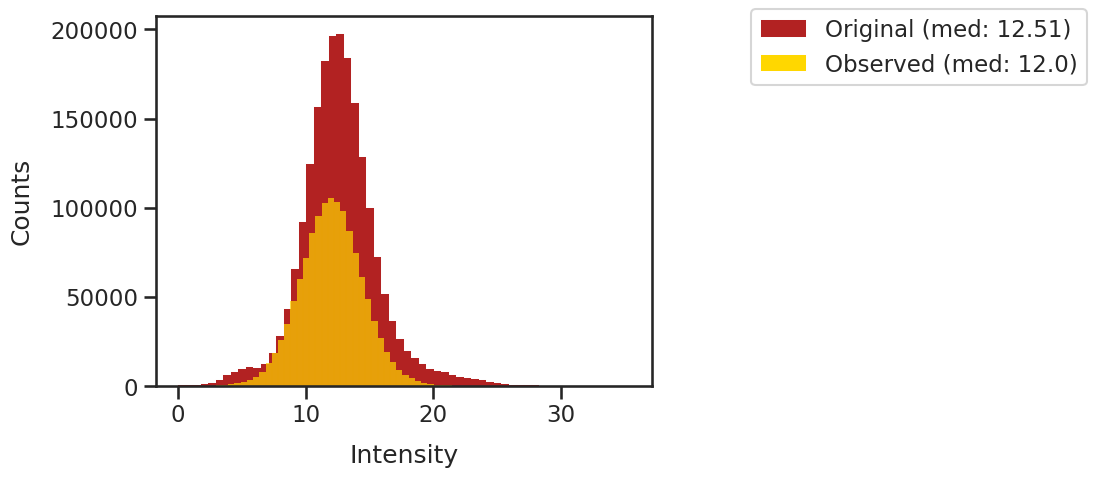

In [679]:
combined_df = pd.concat((condA_df, condB_df), axis=1)
#combined_df.to_csv("../vary-mean-data/quant-simulated-mv-02-p-200.csv")

# What does the distribution of the combined matrix look like? 
#    I don't know, we probably don't want this to be bimodal, right? 
plot_partition_distributions(np.array(combined_df), condA)

#### Write a csv with the ground truth DA proteins as well 

In [680]:
groundtruth_df = pd.DataFrame(columns=["upreg", "downreg"])
upreg_ensp = list(combined_df.iloc[upreg_idx].index)
downreg_ensp = list(combined_df.iloc[downreg_idx].index)

groundtruth_df["upreg"] = upreg_ensp
groundtruth_df["downreg"] = downreg_ensp

#groundtruth_df.to_csv("../vary-mean-data/groundtruth-mv-02-p-200.csv")